# 🧠 03 - Creative Feature Engineering

In this notebook, we move beyond basic preprocessing to construct **innovative behavioral features**, apply **transformative encoding** and **robust scaling**, and use a baseline model to **extract feature importance**.

Let's transform our clean data into a high-signal dataset ready for advanced modeling!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## 1. Load Cleaned Dataset

In [2]:
df = pd.read_csv('../data/telco_churn_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 21)


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 2. Behavioral Feature Engineering

Instead of just using `tenure` or `monthly_charges`, let's create derived features that capture the **behavior** and **value** of a customer over time.

In [3]:
# 1. Tenure Groups (Binning)
def bin_tenure(tenure):
    if tenure <= 12: return '0-1 Year'
    elif tenure <= 24: return '1-2 Years'
    elif tenure <= 36: return '2-3 Years'
    elif tenure <= 48: return '3-4 Years'
    elif tenure <= 60: return '4-5 Years'
    else: return '5+ Years'

df['tenure_group'] = df['tenure'].apply(bin_tenure)

# 2. Number of Additional Services
# Customers with more services might be more 'locked in'
services = ['online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies']
df['num_additional_services'] = df[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

# 3. Average Charge Per Tenure Month
# This compares their actual total to what we expect, helping find anomalies or discount users.
# Adding 1 to tenure to avoid division by zero for new customers
df['avg_charge_per_month'] = df['total_charges'] / (df['tenure'] + 1)

# 4. High Value Customer Flag
# Top 25% of monthly charges are considered high value
high_val_threshold = df['monthly_charges'].quantile(0.75)
df['is_high_value'] = (df['monthly_charges'] > high_val_threshold).astype(int)

df[['tenure', 'tenure_group', 'num_additional_services', 'monthly_charges', 'avg_charge_per_month', 'is_high_value']].head()

,tenure,tenure_group,num_additional_services,monthly_charges,avg_charge_per_month,is_high_value
0,1,0-1 Year,1,29.85,14.925000,0
1,34,2-3 Years,2,56.95,53.985714,0
2,2,0-1 Year,2,53.85,36.050000,0
3,45,3-4 Years,3,42.30,40.016304,0
4,2,0-1 Year,0,70.70,50.550000,0


## 3. Transformative Encoding

We have a mix of binary and multi-class categorical variables. We will:
- **Drop** `customer_id` (not useful for prediction).
- **One-Hot Encode** multi-class categorical variables.

In [4]:
# Drop ID
if 'customer_id' in df.columns:
    df.drop('customer_id', axis=1, inplace=True)

# Identify columns
target = 'churn'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
if target in numerical_cols:
    numerical_cols.remove(target) # target is already 0/1 numeric
if 'is_high_value' in numerical_cols:
    numerical_cols.remove('is_high_value') # keep as binary

print(f"Categorical features: {len(categorical_cols)}")
print(f"Numerical features: {len(numerical_cols)}")

# One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Categorical features: 17
Numerical features: 5
Shape after encoding: (7043, 32)


,tenure,monthly_charges,total_charges,churn,num_additional_services,avg_charge_per_month,is_high_value,gender_Male,senior_citizen_Yes,partner_Yes,...,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,tenure_group_1-2 Years,tenure_group_2-3 Years,tenure_group_3-4 Years,tenure_group_4-5 Years,tenure_group_5+ Years
0,1,29.85,29.85,0,1,14.925000,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
1,34,56.95,1889.50,0,2,53.985714,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
2,2,53.85,108.15,1,2,36.050000,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
3,45,42.30,1840.75,0,3,40.016304,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2,70.70,151.65,1,0,50.550000,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


## 4. Advanced Scaling

We use **RobustScaler** on our continuous numerical features (`tenure`, `monthly_charges`, `total_charges`, `avg_charge_per_month`, `num_additional_services`). RobustScaler uses statistics that are robust to outliers (median and IQR).

In [5]:
scaler = RobustScaler()

cols_to_scale = ['tenure', 'monthly_charges', 'total_charges', 'avg_charge_per_month', 'num_additional_services']
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

df_encoded[cols_to_scale].head()

,tenure,monthly_charges,total_charges,avg_charge_per_month,num_additional_services
0,-0.608696,-0.745170,-0.402798,-0.782675,-0.333333
1,0.108696,-0.246550,0.146087,-0.118256,0.000000
2,-0.586957,-0.303588,-0.379687,-0.423341,0.000000
3,0.347826,-0.516099,0.131698,-0.355874,0.333333
4,-0.586957,0.006440,-0.366848,-0.176697,-0.666667


## 5. Signal Extraction (Feature Importance)

Before we move to full model building, let's train a quick Random Forest to see which features provide the most **signal**.

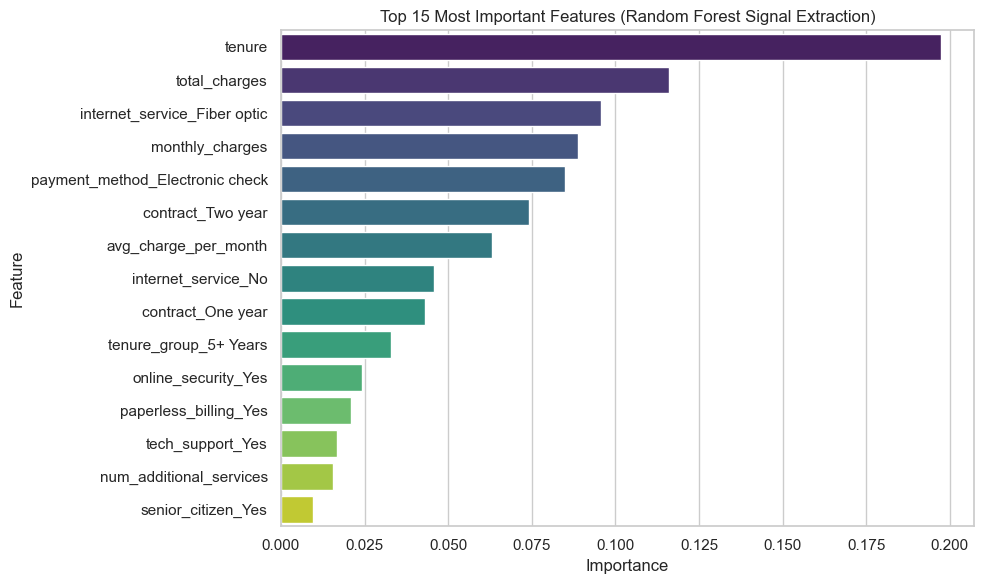

In [6]:
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Quick RF model
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=7)
rf.fit(X, y)

# Get Feature Importances
importances = rf.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest Signal Extraction)')
plt.tight_layout()
plt.show()

## 6. Save Engineered Dataset

We now have a fully engineered, encoded, and scaled dataset ready for rigorous model building!

In [7]:
output_path = '../data/telco_churn_engineered.csv'
df_encoded.to_csv(output_path, index=False)
print(f"Engineered dataset saved to: {output_path}")

Engineered dataset saved to: ../data/telco_churn_engineered.csv
